In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import glob

* compare the acceptance rates of the nested sampling constraint vs the energy of the corresponding dead config

in the acc.rate file, the columns are: i - sample; acc.rate; energy

In [ ]:
ptd = "out_data/ns_constraint_72_N21_100trials/"
data = np.loadtxt(os.path.join(ptd,"acceptance_rate.dat"))
data.shape

(699, 3)

Text(0.5, 0, 'Nested sampling steps')

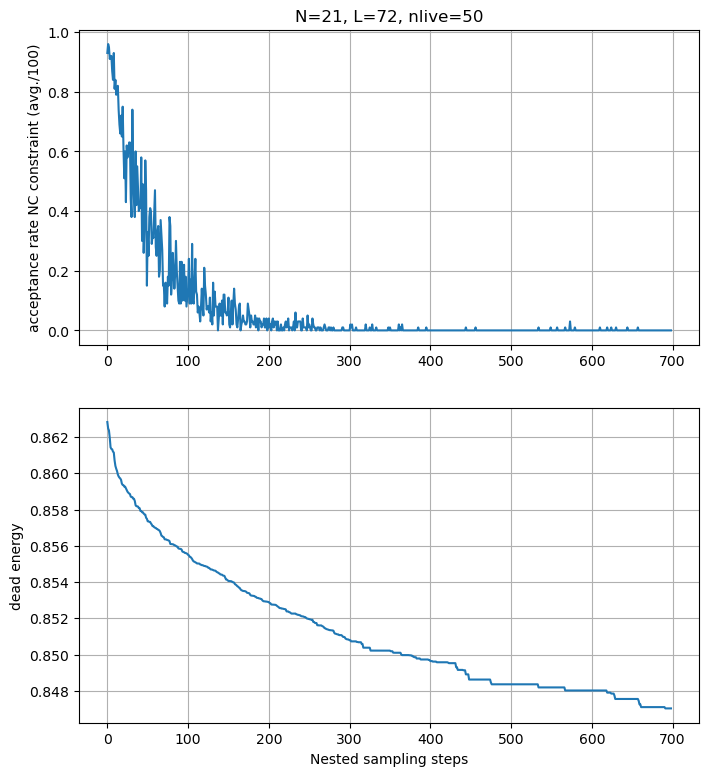

In [24]:
fig, axs = plt.subplots(2, 1, figsize=(8, 9))
axs[0].plot(data[:,1])
axs[0].set_ylabel("acceptance rate NC constraint (avg./100)")
axs[0].grid()
axs[1].plot(data[:,2])
axs[1].set_ylabel("dead energy")
axs[1].grid()

axs[0].set_title("N=21, L=72, nlive=50")
axs[1].set_xlabel("Nested sampling steps")

Text(0.5, 1.0, 'Constraint vs dead E')

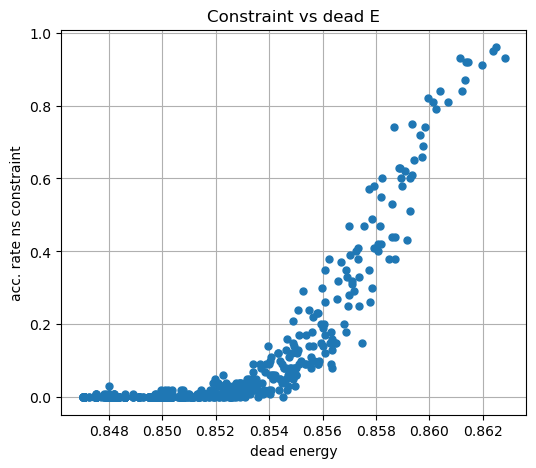

In [4]:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data[:,2], data[:,1], marker="o", markersize=5, linestyle="None")
plt.grid()
plt.xlabel("dead energy")
plt.ylabel("acc. rate ns constraint")
plt.title("Constraint vs dead E")

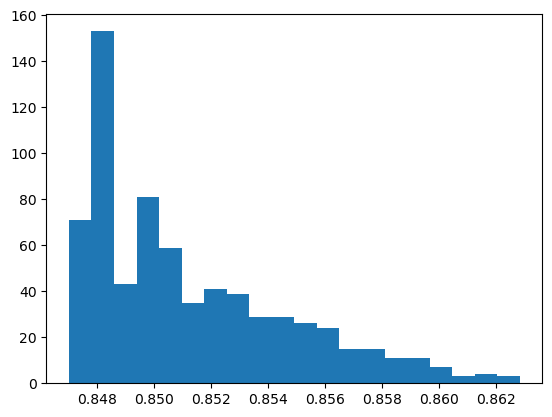

In [5]:
_=plt.hist(data[:,2], bins=20)

# look also at other quantities

similar to the checking_ns_heatbath.ipynb

In [6]:
""" 
the cols in the files are: 
gen_data:
    [0]: Conf. update index
    [1]: energy density S/(2NVb)
    [2]: magn_susc G(p=0)
    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)

topo_data:
    [0]: Conf. update index
    [1]: cooling step
    [2]: geom. top.charge Q_U
    [3]: geom. magn_susc_U
    [4]: geom. top.charge Q_z
    [5]: geom. magn_susc_z
    [6]: non-geom topo charge ~ plaquette
    [7]: non-geom topo susc ~ plaquette
"""

' \nthe cols in the files are: \ngen_data:\n    [0]: Conf. update index\n    [1]: energy density S/(2NVb)\n    [2]: magn_susc G(p=0)\n    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)\n\ntopo_data:\n    [0]: Conf. update index\n    [1]: cooling step\n    [2]: geom. top.charge Q_U\n    [3]: geom. magn_susc_U\n    [4]: geom. top.charge Q_z\n    [5]: geom. magn_susc_z\n    [6]: non-geom topo charge ~ plaquette\n    [7]: non-geom topo susc ~ plaquette\n'

In [7]:
L, T = 72, 72
V = L*T

N = 21
beta = 0.6

n_cool_step = 50     # number of cooling steps 
meas_cool_every = 5
skip_topo = n_cool_step // meas_cool_every + 1

# action prefactor 
pf = 2#beta #*N*V

In [8]:
gen_df  = "dati.dat"
topo_df = "topo.dat"

gen_data = np.loadtxt(os.path.join(ptd,gen_df))
topo_data = np.loadtxt(os.path.join(ptd,topo_df))

In [9]:
print(gen_data.shape, topo_data.shape)

order = np.argsort(gen_data[:,1])[::-1]   # sort after the action vals, from largest to smallest

(700, 4) (7700, 8)


In [10]:
## for gen_data~[N, m], topo_data~[N*skip_topo, k]:
gen_sorted = gen_data[order]

# reshape topo_data into (N, skip_topo, k)
topo_blocks = topo_data.reshape(len(gen_data), skip_topo, -1)

# reorder the blocks
topo_sorted = topo_blocks[order]

# if needed, flatten back to the original shape
topo_sorted = topo_sorted.reshape(-1, topo_data.shape[1])

print(gen_sorted.shape, "\n", topo_sorted.shape)

(700, 4) 
 (7700, 8)


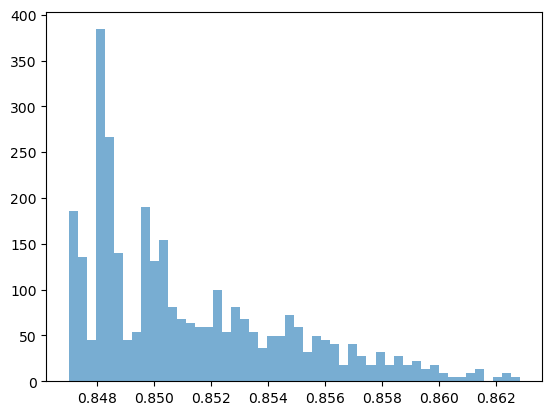

In [11]:
_=plt.hist(gen_sorted[:,1], bins=50, alpha=0.6, density=True)

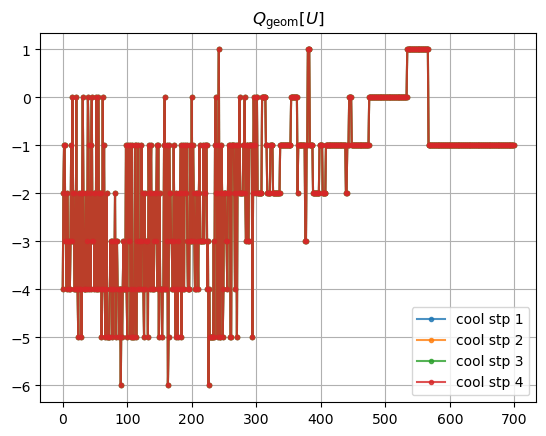

(-5.0, 5.0)

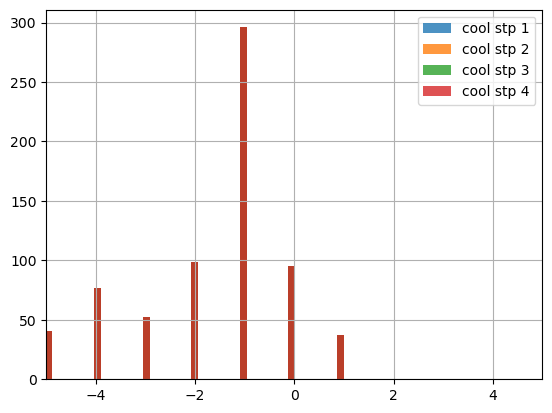

In [12]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, bins=50, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.xlim(-5,5)

# compare to the proficiency with two instead of four microcanonical update steps

# and can we also check the efficiency of the von-Neumann-test step?

In [6]:
ptd2 = "out_data/ns_constraint_72_N21_100trials_2/"
data2 = np.loadtxt(os.path.join(ptd2,"acceptance_rate.dat"))
print(data2.shape)

ptd3 = "out_data/ns_constraint_72_N21_100trials_3/"
data3 = np.loadtxt(os.path.join(ptd3,"acceptance_rate.dat"))
print(data3.shape)

(1149, 3)
(574, 5)


Text(0.5, 0, 'Nested sampling steps')

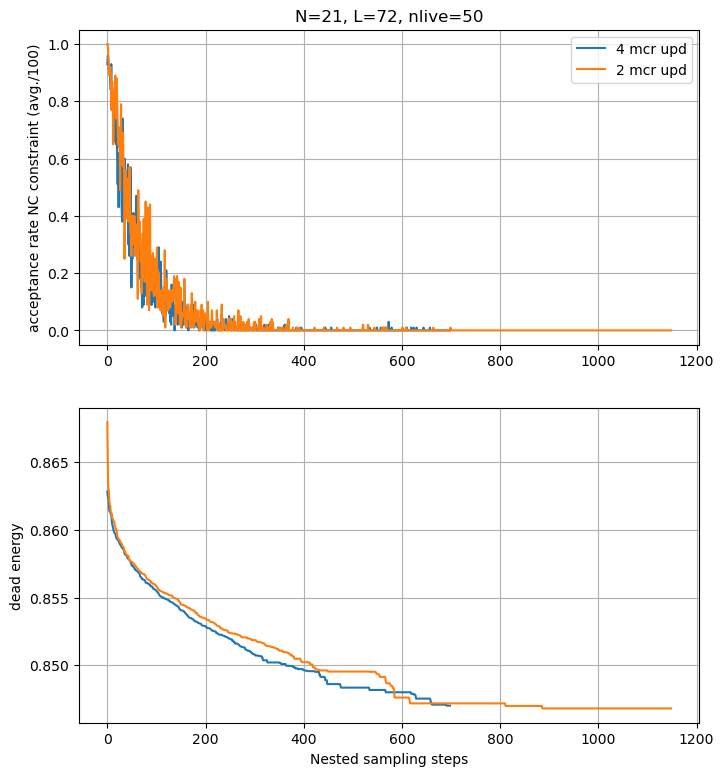

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(8, 9))
axs[0].plot(data[:,1], label="4 mcr upd")
axs[0].plot(data2[:,1], label="2 mcr upd")
axs[0].set_ylabel("acceptance rate NC constraint (avg./100)")
axs[0].grid()
axs[1].plot(data[:,2])
axs[1].plot(data2[:,2])
axs[1].set_ylabel("dead energy")
axs[1].grid()

axs[0].legend()

axs[0].set_title("N=21, L=72, nlive=50")
axs[1].set_xlabel("Nested sampling steps")

Text(0.5, 1.0, 'Constraint vs dead E')

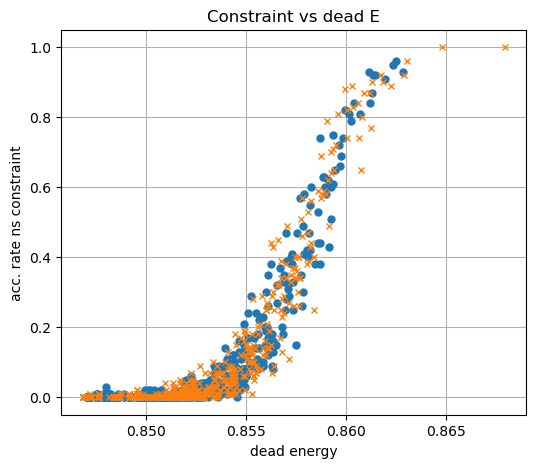

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data[:,2], data[:,1], marker="o", markersize=5, linestyle="None")
axs.plot(data2[:,2], data2[:,1], marker="x", markersize=5, linestyle="None")
plt.grid()
plt.xlabel("dead energy")
plt.ylabel("acc. rate ns constraint")
plt.title("Constraint vs dead E")

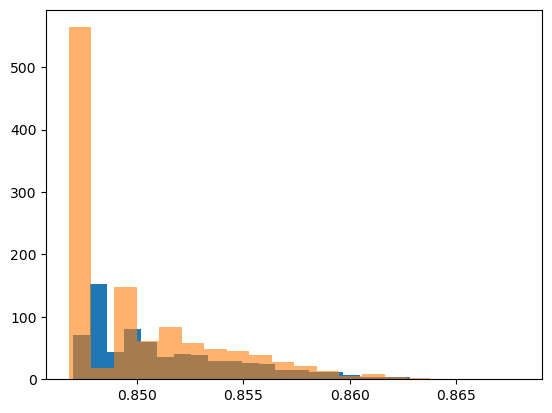

In [46]:
_=plt.hist(data[:,2], bins=20)
_=plt.hist(data2[:,2], bins=20, alpha=0.6)

Text(0.5, 1.0, 'von Neumann efficiency vs dead E (2 micro upd)')

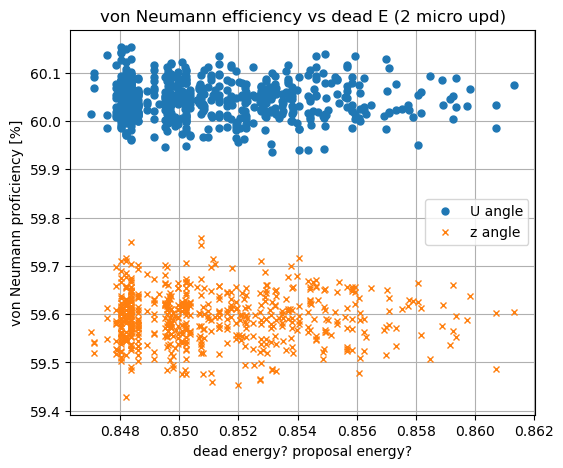

In [47]:
# now also look at the performance of the von Neumann tests:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data3[:,2], 1/data3[:,-2] * 100, marker="o", markersize=5, linestyle="None", label="U angle")
axs.plot(data3[:,2], 1/data3[:,-1] * 100, marker="x", markersize=5, linestyle="None", label="z angle")
plt.grid()
plt.legend()
plt.xlabel("dead energy? proposal energy?")
plt.ylabel("von Neumann proficiency [%]")
plt.title("von Neumann efficiency vs dead E (2 micro upd)")

Text(0.5, 1.0, 'von Neumann efficiency vs dead E (4 micro upd)')

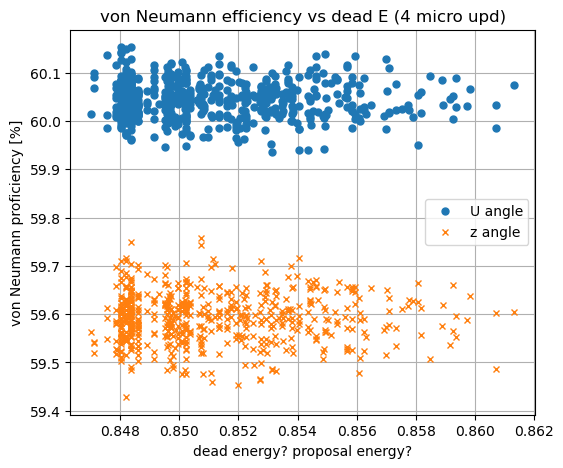

In [48]:
# now also look at the performance of the von Neumann tests:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data3[:,2], 1/data3[:,-2] * 100, marker="o", markersize=5, linestyle="None", label="U angle")
axs.plot(data3[:,2], 1/data3[:,-1] * 100, marker="x", markersize=5, linestyle="None", label="z angle")
plt.grid()
plt.legend()
plt.xlabel("dead energy? proposal energy?")
plt.ylabel("von Neumann proficiency [%]")
plt.title("von Neumann efficiency vs dead E (4 micro upd)")

# look at the single link/site updates

In [ ]:
ptd2 = "out_data/ns_constraint_72_N21_100trials_stoc5000/"
data2 = np.loadtxt(os.path.join(ptd2,"acceptance_rate.dat"))    # iteration | single site | single U | live energy
dE2 = np.loadtxt(os.path.join(ptd2,"dati.dat"))
print(data2.shape)
print(dE2.shape)

## more stochastic updates:
# ptd3 = "out_data/ns_constraint_72_N21_100trials_stoc15500/"
# data3 = np.loadtxt(os.path.join(ptd3,"acceptance_rate.dat"))    # iteration | single site | single U | live energy
# dE3 = np.loadtxt(os.path.join(ptd3,"dati.dat"))

# print(data3.shape)
# print(dE3.shape)

## only stochastic heatbath, microcan else
ptd3 = "out_data/ns_constraint_72_N21_1000ns_stoc15500/"
data3 = np.loadtxt(os.path.join(ptd3,"acceptance_rate.dat"))    # iteration | single site | single U | live energy
dE3 = np.loadtxt(os.path.join(ptd3,"dati.dat"))

print(data3.shape)
print(dE3.shape)

(1999, 4)
(2000, 4)
(1354, 4)
(1357, 4)


Text(0.5, 0, 'Nested sampling steps')

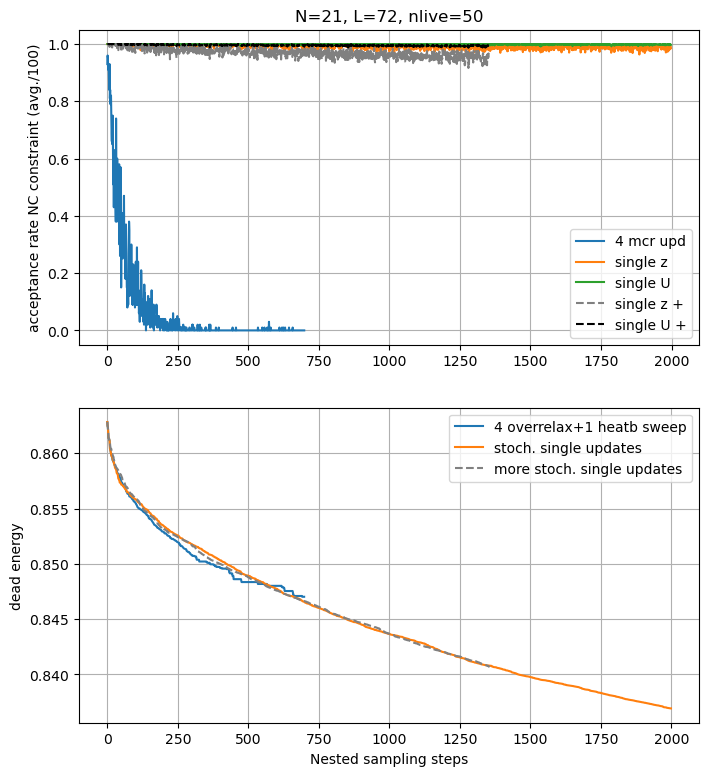

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(8, 9))
axs[0].plot(data[:,1], label="4 mcr upd")
axs[0].plot(data2[:,1], label="single z")
axs[0].plot(data2[:,2], label="single U")
axs[0].plot(data3[:,1], label="single z +", color="gray", linestyle="--")
axs[0].plot(data3[:,2], label="single U +", color="black", linestyle="--")
axs[0].set_ylabel("acceptance rate NC constraint (avg./100)")
axs[0].grid()
axs[0].legend()


axs[1].plot(data[:,2], label="4 overrelax+1 heatb sweep")
axs[1].plot(dE2[:,1], label="stoch. single updates")
axs[1].plot(dE3[:,1], label="more stoch. single updates", linestyle="--", color="gray")
axs[1].set_ylabel("dead energy")
axs[1].grid()
axs[1].legend()

axs[0].set_title("N=21, L=72, nlive=50")
axs[1].set_xlabel("Nested sampling steps")

Text(0.5, 1.0, 'Constraint vs dead E')

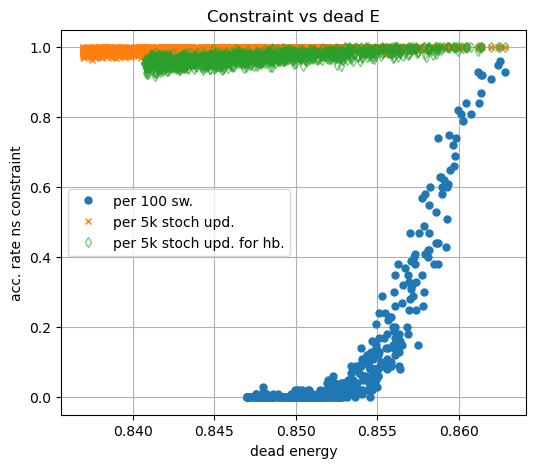

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data[:,2], data[:,1], marker="o", markersize=5, linestyle="None", label="per 100 sw.")
axs.plot(dE2[:-1,1], data2[:,1], marker="x", markersize=5, linestyle="None", label="per 5k stoch upd.")
axs.plot(dE3[:len(data3),1], data3[:,1], marker="d", markerfacecolor="None", alpha=0.6, markersize=5, linestyle="None", label="per 5k stoch upd. for hb.")
plt.grid()
plt.legend()
plt.xlabel("dead energy")
plt.ylabel("acc. rate ns constraint")
plt.title("Constraint vs dead E")

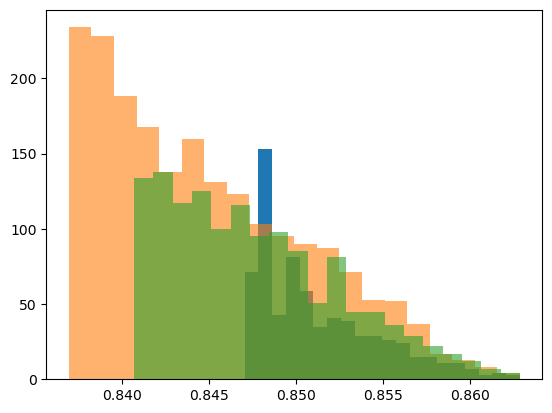

In [16]:
_=plt.hist(data[:,2], bins=20)      # is dead energy
_=plt.hist(dE2[:,1], bins=20, alpha=0.6)  # is the live energy?
_=plt.hist(dE3[:,1], bins=20, alpha=0.6)  # is the live energy?

# look at observables for the single link/site update ds:

In [17]:
L, T = 72, 72
V = L*T

N = 21
beta = 0.6

n_cool_step = 50     # number of cooling steps 
meas_cool_every = 5
skip_topo = n_cool_step // meas_cool_every + 1

# action prefactor 
pf = 2#beta #*N*V

In [18]:
gen_df  = "dati.dat"
topo_df = "topo.dat"

gen_data = np.loadtxt(os.path.join(ptd3,gen_df))
topo_data = np.loadtxt(os.path.join(ptd3,topo_df))

In [19]:
print(gen_data.shape, topo_data.shape)

order = np.argsort(gen_data[:,1])[::-1]   # sort after the action vals, from largest to smallest

(1357, 4) (14927, 8)


In [20]:
## for gen_data~[N, m], topo_data~[N*skip_topo, k]:
gen_sorted = gen_data[order]

# reshape topo_data into (N, skip_topo, k)
topo_blocks = topo_data.reshape(len(gen_data), skip_topo, -1)

# reorder the blocks
topo_sorted = topo_blocks[order]

# if needed, flatten back to the original shape
topo_sorted = topo_sorted.reshape(-1, topo_data.shape[1])

print(gen_sorted.shape, "\n", topo_sorted.shape)

(1357, 4) 
 (14927, 8)


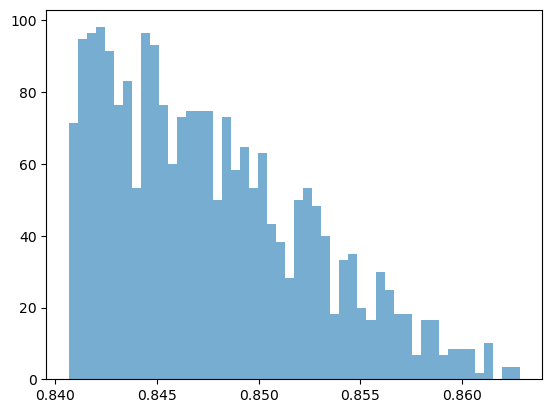

In [21]:
_=plt.hist(gen_sorted[:,1], bins=50, alpha=0.6, density=True)

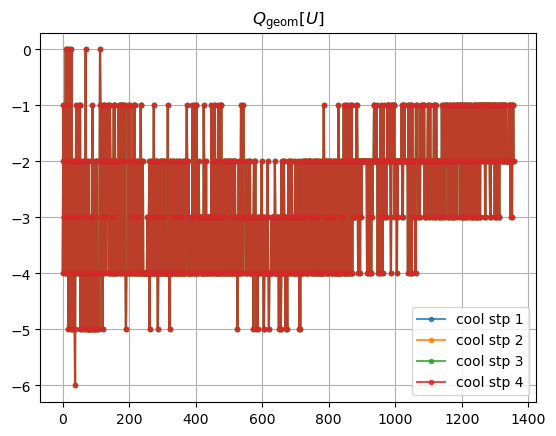

(-5.0, 5.0)

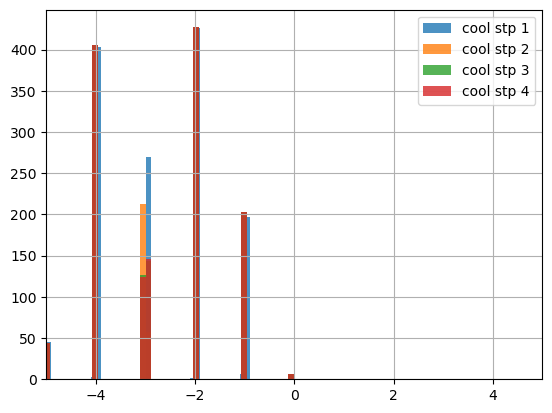

In [22]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, bins=50, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.xlim(-5,5)

we seem to be stuck within one topological sector at some point!

In [399]:
n_live = 50
n_iter = 1
n_live_eff = n_iter * n_live

In [400]:
gen_data  = gen_sorted
topo_data = topo_sorted

energies = 2*gen_data[:,1]

print(gen_data.shape, "\n", topo_data.shape)

(1353, 4) 
 (14883, 8)


In [401]:
n_meas = len(gen_data)
print(n_meas)

1353


In [402]:
# similar to Simone Romiti's lattice tools: https://github.com/simone-romiti/lattice_data_tools/tree/main

# get set of Beta-distributed vals X_i
# rng = np.random.default_rng()
#t_list = rng.beta(n_live, 1, size=(n_meas,))
# x_list = np.cumprod(t_list)

## simple approach:
log_t = (-1.0/n_live_eff) * np.ones(n_meas)
t_list = np.exp(log_t)

# get log(x)
log_x = np.cumsum(log_t)
x_list = np.exp(log_x)
h_list = np.exp(log_x[:-1]) - np.exp(log_x[1:])
#print(log_x.shape)

# get log(w) (fwd definition ~ w_i = x_i-1 - x_i)
log_w = log_x  + np.log(1.0 - t_list)

In [403]:
# get log(w)
"""log_w0 = 0
log_w = [np.log(1-t_list[0])]
for i in range(1, len(t_list-1)):
    log_w0 += np.log(t_list[i-1])
    log_w.append(log_w0-np.log(1-t_list[i]))

log_w = np.array(log_w)"""

'log_w0 = 0\nlog_w = [np.log(1-t_list[0])]\nfor i in range(1, len(t_list-1)):\n    log_w0 += np.log(t_list[i-1])\n    log_w.append(log_w0-np.log(1-t_list[i]))\n\nlog_w = np.array(log_w)'

In [404]:
from scipy.special import logsumexp

In [405]:
# get normalized weights: (L=1 here since it is part of the prior!)
log_Z_unnorm = logsumexp(log_w)
log_w_norm = log_w - log_Z_unnorm

In [406]:
# from Simones tools:
def get_log_Z_curve(log_wL_normalized: np.ndarray):
    """
    The partition function is normalized to 1.
    The total weights w_i*L_i are the discrete version of the probability density function.
    The cumulative sum of the total weights gives use the cumulative density function. This function returns the log of that curve.
    """
    n_iter = log_wL_normalized.shape[0]
    s = log_wL_normalized[0]
    logZ = [s]
    for i in range(n_iter-1):
        s = np.logaddexp(s, log_wL_normalized[i+1])
        logZ.append(s)
    #---
    res = np.array(logZ)
    return res

Text(0, 0.5, 'Z')

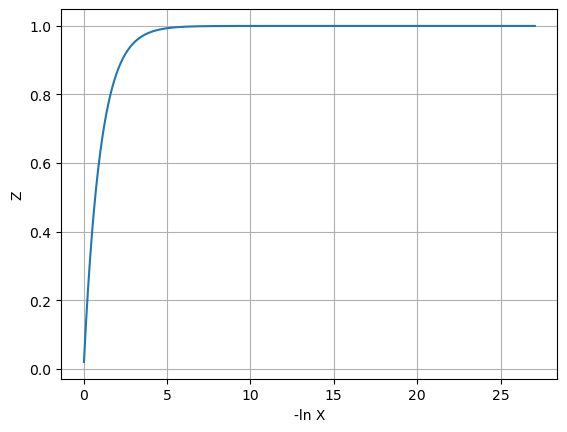

In [407]:
log_Z_curve = get_log_Z_curve(log_w_norm)
plt.plot(-log_x,np.exp(log_Z_curve))

plt.grid()
plt.xlabel("-ln X")
plt.ylabel("Z")

In [408]:
# does it do the same as the function above? yes!
log_Z = []
for i in range(len(energies)):
    log_Z.append(logsumexp(log_w[:i]))  #-energies[:i]+
log_Z = np.array(log_Z)
log_Z_norm = log_Z[-1]
log_Z -= log_Z_norm
log_Z.shape
# log_Z_tot = logsumexp(-energies+log_w)

(1353,)

Text(0, 0.5, 'Z')

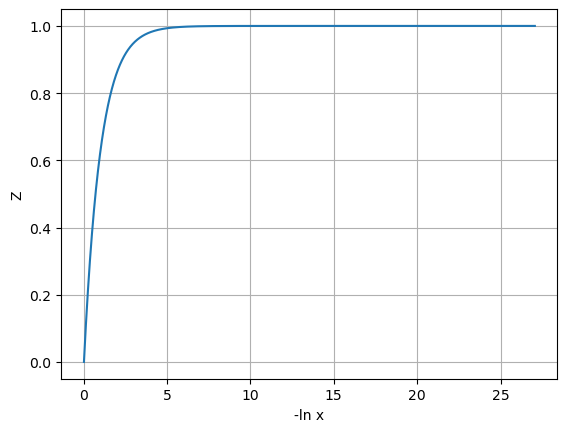

In [409]:
plt.plot(-np.log(x_list[:]), np.exp(log_Z))       #
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("Z")

In [410]:
log_Z = []
for i in range(len(energies)):
    log_Z.append(logsumexp(log_w_norm[:i]))  #-energies[:i]+
log_Z = np.array(log_Z)
log_Z.shape
# log_Z_tot = logsumexp(-energies+log_w)

(1353,)

Text(0, 0.5, 'Z')

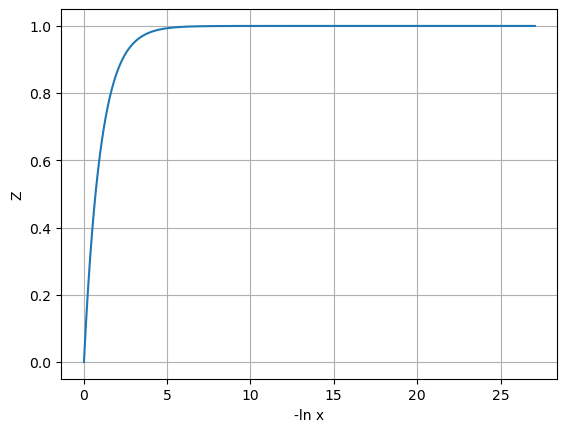

In [411]:
plt.plot(-np.log(x_list[:]), np.exp(log_Z))       #
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("Z")

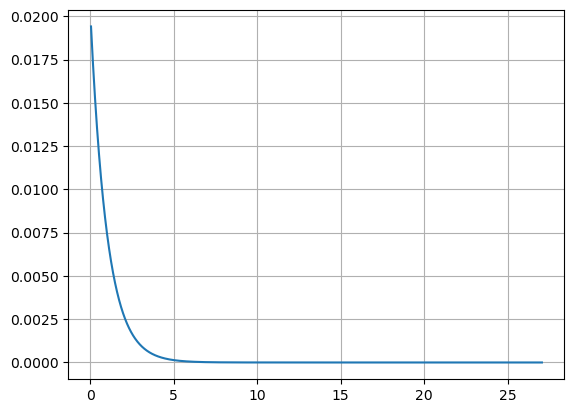

In [412]:
plt.plot(-np.log(x_list[1:]), h_list)       #np.exp(Z_can)*
plt.grid()

Text(0, 0.5, 'counts')

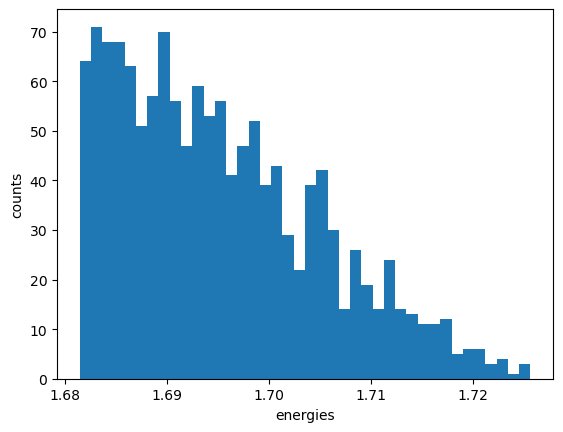

In [413]:
energies = 2*gen_data[:,1]
_=plt.hist(energies, bins=40)
plt.xlabel("energies")
plt.ylabel("counts")

In [414]:
avg_obs = np.sum(np.exp(log_w_norm)*energies)
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t1.716722(2)")

1.717090673537821
Thesis result for b=0.6, L=72, N=21:	1.716722(2)


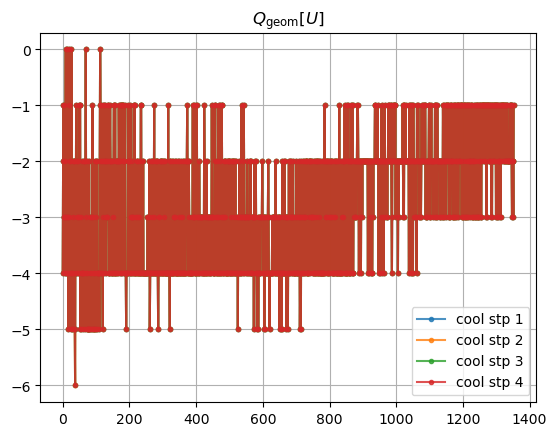

(-5.0, 5.0)

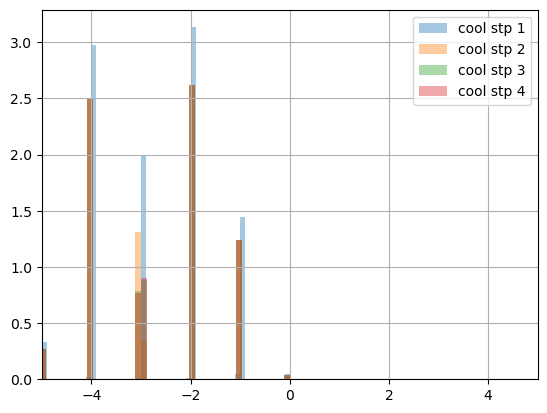

In [415]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
topo_idx = 2        # 2 geom, 6 nongeom
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,topo_idx][:40000], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,topo_idx][:], alpha=0.4, bins=50, label=f"cool stp {cool_stp}", density=True)
plt.grid()
plt.legend()
plt.xlim(-5,5)

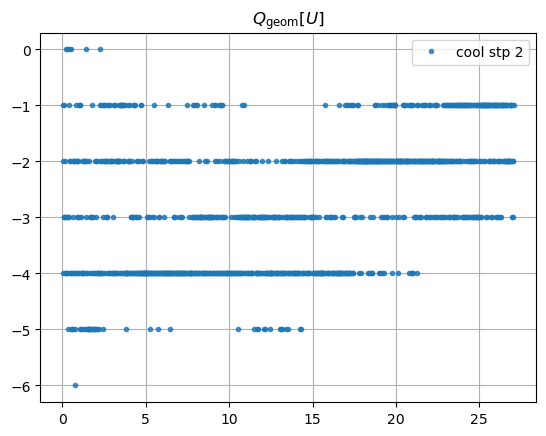

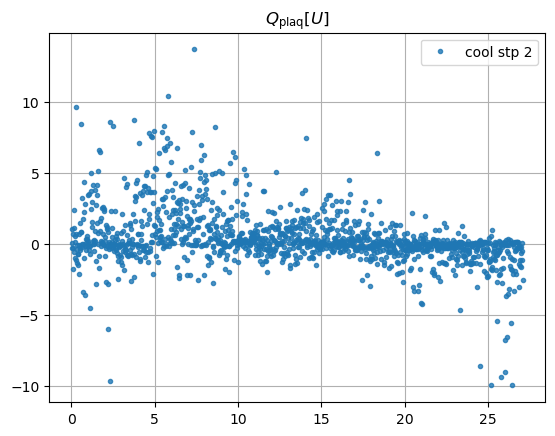

In [416]:
cool_stp = 2    # translates to meas_every_cool... * cool_stp cooling steps
topo_idx = 2        # 2 geom, 6 nongeom

plt.plot(-np.log(x_list[:]), topo_sorted[cool_stp::skip_topo,topo_idx][:], alpha=0.8, marker="o", linestyle="None", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

topo_idx = 6        # 2 geom, 6 nongeom

plt.plot(-np.log(x_list[:]), topo_sorted[cool_stp::skip_topo,topo_idx][:], alpha=0.8, marker="o", linestyle="None", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{plaq}[U]$")
plt.show()

In [417]:
log_w_norm.shape

(1353,)

In [418]:
c_step = 3
#obs = topo_data[c_step::skip_topo,2]
obs = topo_data[c_step::skip_topo,6]
print(obs.shape)

avg_obs = np.sum(np.exp(log_w_norm)*obs)
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t0.002(3)")
print("This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!")

(1353,)
0.635685593142014
Thesis result for b=0.6, L=72, N=21:	0.002(3)
This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!


In [419]:
k = 2*np.pi / L

In [420]:
obs_0 = gen_data[:,2]
obs_k = gen_data[:,3]

avg_obs_0 = np.sum(np.exp(log_w_norm)*obs_0)
avg_obs_k = np.sum(np.exp(log_w_norm)*obs_k)

xi_L2 = 1 / (4 * np.sin(k/2)**2) * (avg_obs_0/avg_obs_k - 1.)
print(f"xi_L={np.sqrt(xi_L2)}")

print("Thesis result for b=0.6, L=72, N=21:\t2.895(7)")

xi_L=4.459789635338939
Thesis result for b=0.6, L=72, N=21:	2.895(7)
